In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay, recall_score, precision_score, f1_score
)
import shap
import joblib
import matplotlib.pyplot as plt

data_path = 'data/'

#Loading relevant tables
student_info = pd.read_csv(data_path + 'studentInfo.csv')
student_vle = pd.read_csv(data_path + 'studentVle.csv')
student_assessment = pd.read_csv(data_path + 'studentAssessment.csv')
assessments = pd.read_csv(data_path + 'assessments.csv')




FileNotFoundError: [Errno 2] No such file or directory: 'data/studentInfo.csv'

,The Oulad dataset is relational so we need to load the different datasets and merge them together
we start from the studentInfo as the base table
aggregate StudentVle to student level
merge studentAssessment with assessments
aggregate assessment data to student level
merge engineered features back into studentInfo
,


In [39]:
#creating the target variable
student_info['at_risk'] = student_info['final_result'].apply(
    lambda x: 1 if x in ['Fail', 'Withdrawn'] else 0
)

#early days is the time limit in which the model can access to come up with a result as we are chasing early intervention so we filter out the results after 30 days
early_days = 30
early_vle = student_vle[student_vle['date'] <= early_days]

# features for the learning environment
vle_features = (
    early_vle
    .groupby(['id_student', 'code_module', 'code_presentation'])
    .agg(
        total_clicks=('sum_click', 'sum'),
        avg_clicks=('sum_click', 'mean'),
        vle_records=('sum_click', 'count')
    )
    .reset_index()
)

# full assessment details
assessment_full = student_assessment.merge(
    assessments,
    on='id_assessment',
    how='left'
)

# we do the same filtering process for the assessment data we merge and then filter for the first 30 days
early_assessments = assessment_full[assessment_full['date_submitted'] <= early_days]

assessment_features = (
    early_assessments
    .groupby(['id_student', 'code_module', 'code_presentation'])
    .agg(
        avg_score=('score', 'mean'),
        assessment_count=('score', 'count'),
    )
    .reset_index()
)

#merge all tables into one
df = student_info.merge(
    vle_features,
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)

df = df.merge(
    assessment_features,
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)


Handling missing values

In [40]:
#handling nulls
print('Before Handling' ,df.isnull().sum())

#fill nulls with 0 where it makes sense
feature_cols = [
    'total_clicks',
    'avg_clicks',
    'vle_records',
    'avg_score',
    'assessment_count',
]

#fill all numerical columns with 0
df[feature_cols] = df[feature_cols].fillna(0)
#fill imd_band which is a categorical column with 'Unknown'
df['imd_band'] = df['imd_band'].fillna('Unknown')

print('\nAfter Handling',df.isnull().sum())




#dropping final column to ensure no data leakage, student id is kept in place for grouped splitting
df = df.drop(columns=['final_result'])


#So i am creating two datasets for comparison between two models one with the module code and one without the module code
df_with_module = df.copy()
df_without_module = df.drop(columns=['code_module'])


Before Handling code_module                 0
code_presentation           0
id_student                  0
gender                      0
region                      0
highest_education           0
imd_band                 1111
age_band                    0
num_of_prev_attempts        0
studied_credits             0
disability                  0
final_result                0
at_risk                     0
total_clicks             3751
avg_clicks               3751
vle_records              3751
avg_score               11302
assessment_count        11289
dtype: int64

After Handling code_module             0
code_presentation       0
id_student              0
gender                  0
region                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
final_result            0
at_risk                 0
total_clicks            0
avg_clicks              0
vle_records             0

Encoding and Machine learning stage

In [41]:


# turned the training and evaluation into one reusable function so i can compare models with and without certain features
def train_and_evaluate(df_input, model, model_name):
    x = df_input.drop(columns=['at_risk'])
    y = df_input['at_risk']

    #Using student id for grouped splitting
    groups = df_input['id_student']

    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(x, y, groups=groups))

    x_train = x.iloc[train_idx].copy()
    x_test = x.iloc[test_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_test = y.iloc[test_idx].copy()

    #dropping student id after splitting so it is not used as a feature
    x_train = x_train.drop(columns=['id_student'])
    x_test = x_test.drop(columns=['id_student'])

    #encoding after splitting
    x_train = pd.get_dummies(x_train, drop_first=True)
    x_test = pd.get_dummies(x_test, drop_first=True)

    #align columns
    x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)

    #clean column names for XGBoost compatability
    x_train.columns = x_train.columns.str.replace(r'[\[\]<]', '', regex=True)
    x_test.columns = x_test.columns.str.replace(r'[\[\]<]', '', regex=True)

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]

    #metrics
    print(f"\n{model_name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    #confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot()
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    #ROC curve
    RocCurveDisplay.from_predictions(y_test, y_prob)
    plt.title(f"ROC Curve - {model_name}")
    plt.show()

    #feature importance for XGBoost
    importance_df = None
    if hasattr(model, "feature_importances_"):
        importance_df = pd.DataFrame({
            "feature": x_train.columns,
            "importance": model.feature_importances_
        }).sort_values("importance", ascending=False)

        print("\nTop 15 Features:")
        print(importance_df.head(15))

        importance_df.head(15).sort_values("importance").plot(
            x="feature",
            y="importance",
            kind="barh",
            figsize=(10, 6)
        )
        plt.title(f"Top 15 Features - {model_name}")
        plt.show()

    return model, importance_df

#baseline model
lr_model = LogisticRegression(max_iter=3000,solver='liblinear' ,random_state=42)

#xgb model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)




Evaluate the model


Logistic Regression WITH module
Accuracy: 0.7481069386493587
ROC-AUC: 0.8311448590478463
Precision: 0.7731767614338689
Recall: 0.7363154796939376
F1: 0.7542960506481761

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.76      0.74      3073
           1       0.77      0.74      0.75      3398

    accuracy                           0.75      6471
   macro avg       0.75      0.75      0.75      6471
weighted avg       0.75      0.75      0.75      6471



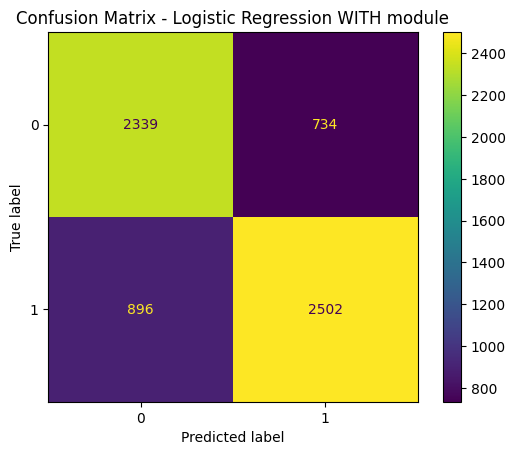

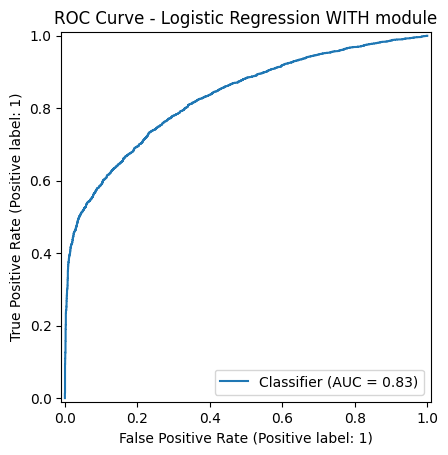


XGBoost WITH module
Accuracy: 0.761087930768042
ROC-AUC: 0.8411528517282136
Precision: 0.8020221787345075
Recall: 0.7236609770453207
F1: 0.7608292079207921

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.80      0.76      3073
           1       0.80      0.72      0.76      3398

    accuracy                           0.76      6471
   macro avg       0.76      0.76      0.76      6471
weighted avg       0.77      0.76      0.76      6471



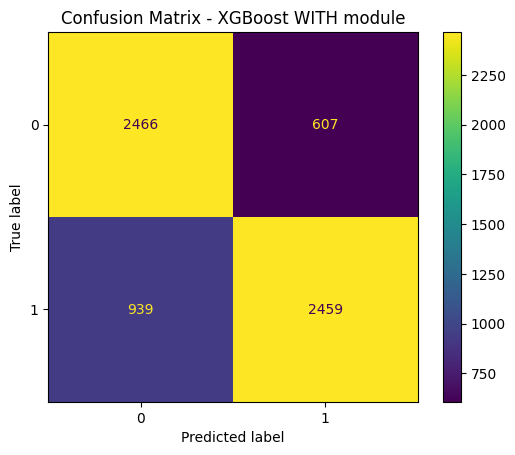

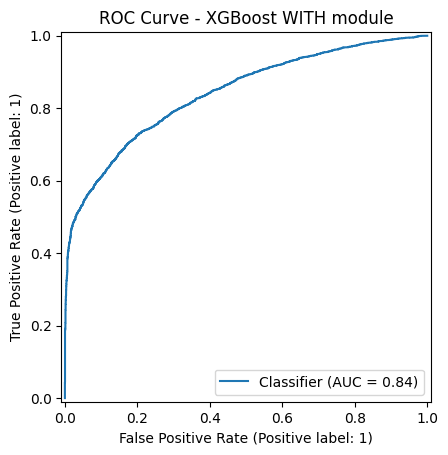


Top 15 Features:
                                 feature  importance
10                       code_module_EEE    0.155086
12                       code_module_GGG    0.151746
5                              avg_score    0.096863
4                            vle_records    0.064429
7                        code_module_BBB    0.042525
11                       code_module_FFF    0.037191
8                        code_module_CCC    0.030139
9                        code_module_DDD    0.029000
30  highest_education_Lower Than A Level    0.026198
6                       assessment_count    0.025972
2                           total_clicks    0.020391
0                   num_of_prev_attempts    0.017786
42                      imd_band_Unknown    0.016407
20                   region_North Region    0.012531
41                      imd_band_90-100%    0.012325


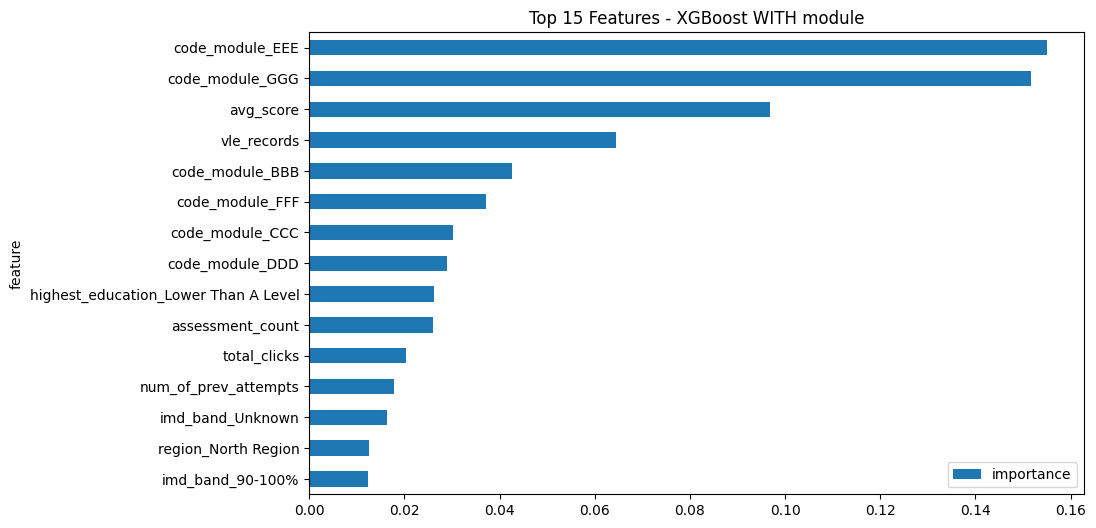


Logistic Regression WITHOUT module
Accuracy: 0.7059187142636377
ROC-AUC: 0.7956951285637864
Precision: 0.7236015554890817
Recall: 0.7118893466745144
F1: 0.717697670968699

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.70      0.69      3073
           1       0.72      0.71      0.72      3398

    accuracy                           0.71      6471
   macro avg       0.71      0.71      0.71      6471
weighted avg       0.71      0.71      0.71      6471



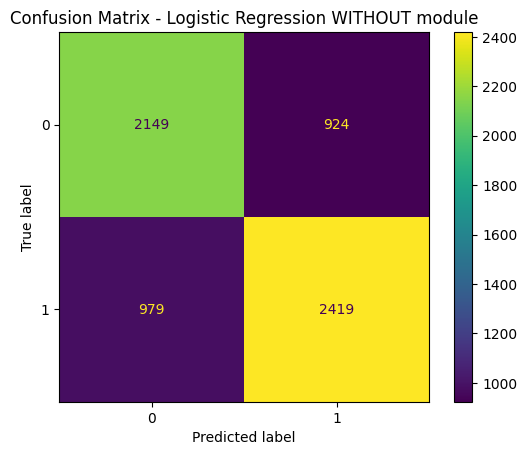

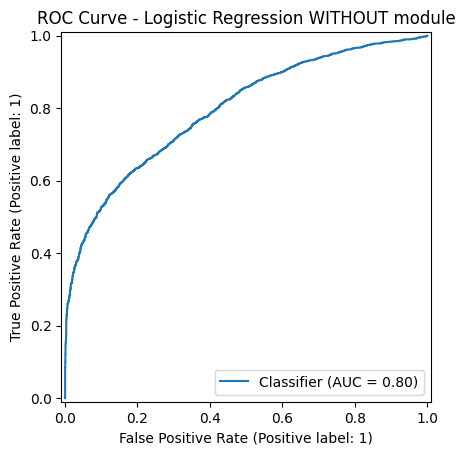


XGBoost WITHOUT module
Accuracy: 0.7459434399629115
ROC-AUC: 0.8306152697543989
Precision: 0.7867887508175277
Recall: 0.7080635668040024
F1: 0.7453531598513011

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.79      0.75      3073
           1       0.79      0.71      0.75      3398

    accuracy                           0.75      6471
   macro avg       0.75      0.75      0.75      6471
weighted avg       0.75      0.75      0.75      6471



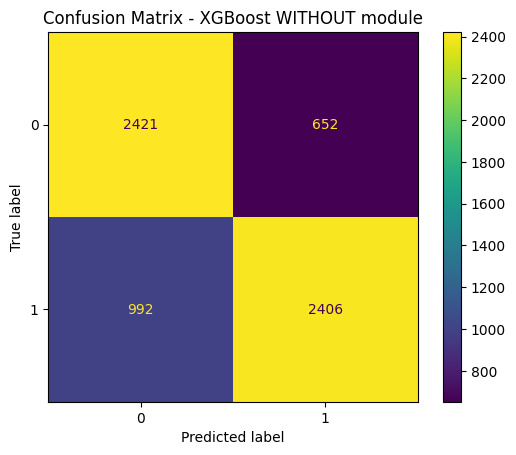

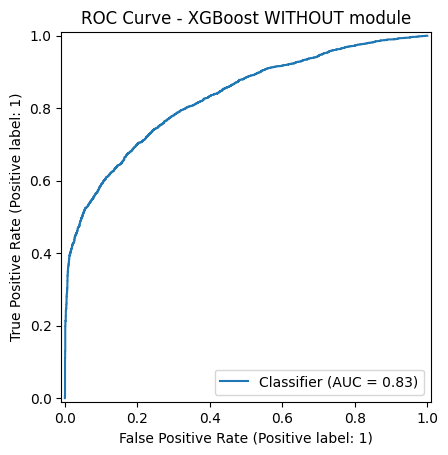


Top 15 Features:
                                 feature  importance
5                              avg_score    0.140510
4                            vle_records    0.100571
1                        studied_credits    0.066428
2                           total_clicks    0.043077
24  highest_education_Lower Than A Level    0.042473
6                       assessment_count    0.040835
0                   num_of_prev_attempts    0.032814
10                              gender_M    0.028204
36                      imd_band_Unknown    0.026454
39                          disability_Y    0.025720
9                code_presentation_2014J    0.023902
35                      imd_band_90-100%    0.021779
25     highest_education_No Formal quals    0.021052
28                       imd_band_20-30%    0.019491
7                code_presentation_2013J    0.017705


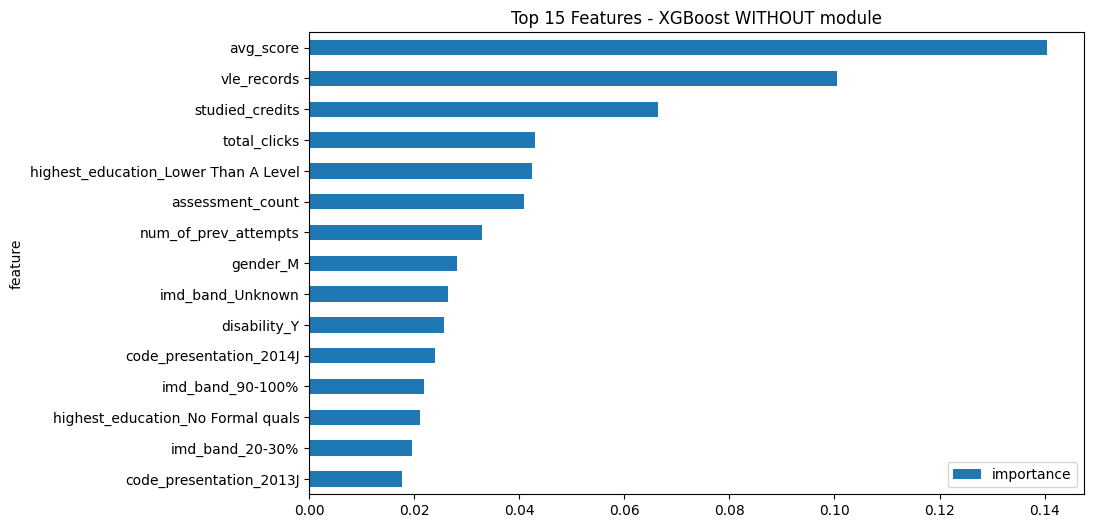

(XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.05, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=200,
               n_jobs=None, num_parallel_tree=None, ...),
                                           feature  importance
 5                                       avg_score    0.140510
 4                                     vle_records    0.100571
 1                                 studied

In [42]:
train_and_evaluate(df_with_module, lr_model, "Logistic Regression WITH module")
train_and_evaluate(df_with_module, xgb_model, "XGBoost WITH module")

train_and_evaluate(df_without_module, lr_model, "Logistic Regression WITHOUT module")
train_and_evaluate(df_without_module, xgb_model, "XGBoost WITHOUT module")

Creating the sample dataset

In [43]:
at_risk_df = df_without_module[df_without_module['at_risk'] == 1]
not_at_risk_df = df_without_module[df_without_module['at_risk'] == 0]

at_risk_sample = at_risk_df.sample(n=100 , random_state=42)
not_at_risk_sample = not_at_risk_df.sample(n = 100 , random_state=42)

demo_df = pd.concat([at_risk_sample, not_at_risk_sample]).sample(frac=1,random_state=42).reset_index(drop=True)

print(demo_df.shape)
print(demo_df['at_risk'].value_counts())


columns_to_keep = [
    'id_student',
    'gender',
    'age_band',
    'highest_education',
    'imd_band',
    'num_of_prev_attempts',
    'studied_credits',
    'disability',
    'region',
    'code_presentation',
    'total_clicks',
    'avg_clicks',
    'vle_records',
    'avg_score',
    'assessment_count',
    'at_risk'
]

demo_df = demo_df[columns_to_keep]

# saved the results to a csv file
#demo_df.to_csv("demo_students.csv", index=False)

(200, 16)
at_risk
1    100
0    100
Name: count, dtype: int64


training final model for deployment

In [44]:
def train_final_model(df_input):
    x = df_input.drop(columns=['at_risk']).copy()
    y = df_input['at_risk'].copy()

    #we drop student id because it is only for ui purposes
    x = x.drop(columns=['id_student'])

    #ENCODING
    x = pd.get_dummies(x, drop_first=True)

    #cleaning column names
    x.columns = x.columns.str.replace(r'[\[\]<]', '', regex=True)

    model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        random_state=42
    )

    model.fit(x, y)

    return model, x.columns.tolist()

final_model, feature_cols = train_final_model(df_without_module)

#saving the models below

#joblib.dump(final_model, "final_xgb_model.pkl")
#joblib.dump(feature_cols, "final_feature_columns.pkl")

#raw_input_columns = df_without_module.drop(columns=['at_risk']).columns.tolist()
#joblib.dump(raw_input_columns, "raw_input_columns.pkl")

['raw_input_columns.pkl']